# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy


---
**Dataset:** COVID-19 in African Countries  
**Source:** https://www.kaggle.com/datasets/anandhuh/covid-in-african-countries-latest-data  
**Features:** Country (non-numeric), Total Cases, Total Deaths, Total Recovered, Active Cases, Total Tests, Population, Tot Cases/1M pop, Deaths/1M pop, Tests/1M pop (10+ columns, contains NaN values ✓)

**Link to our Github:**
https://github.com/acele-happy/Formative2_PCA

**Link to contribution task sheet**
https://docs.google.com/spreadsheets/d/1pLmMgRlOkq5tJKfJ87r2cJlfBXVUXyOzk5cz-Vl4F70/edit?usp=sharing





In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time   # for Task 3 benchmarking


### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

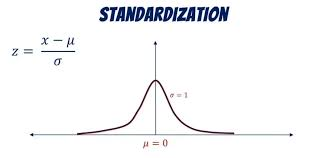


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Mount Google Drive if running in Colab, or adjust path to your local file.
# The CSV should be placed in the same directory as this notebook,
# OR uploaded to /content/ in Colab.

import os

# Try common Colab upload path first, then local
data_path = None
for candidate in ['/content/covid_africa.csv', 'covid_africa.csv',
                  '/content/COVID_Africa.csv', 'COVID_Africa.csv',
                  '/content/africa_covid.csv']:
    if os.path.exists(candidate):
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError(
        "Dataset not found. Please upload 'covid_africa.csv' "
        "to /content/ in Colab (or the notebook's working directory)."
    )

print(f"Loading data from: {data_path}")


Loading data from: /content/covid_africa.csv


In [3]:
# ── Parse CSV with numpy only ─────────────────────────────────────────────────
raw = []
with open(data_path, encoding='utf-8') as f:
    lines = f.read().splitlines()

header = lines[0].split(',')
print("Columns found:", header)
print(f"Total rows (including header): {len(lines)}")


Columns found: ['Country/Other', 'Total Cases', 'Total Deaths', 'Total Recovered', 'Active Cases', 'Tot Cases/ 1M pop', 'Deaths/ 1M pop', 'Total Tests', 'Tests/ 1M pop', 'Population']
Total rows (including header): 55


In [4]:
# ── Separate non-numeric (Country) from numeric columns ──────────────────────
# Column 0 = Country (non-numeric) ← satisfies assignment requirement
country_col_idx = 0
numeric_col_indices = list(range(1, len(header)))

countries = []
raw_numeric = []

for line in lines[1:]:         # skip header
    parts = line.split(',')
    if len(parts) < len(header):
        continue               # skip malformed rows
    countries.append(parts[country_col_idx].strip())
    row_vals = []
    for i in numeric_col_indices:
        val = parts[i].strip().replace(',', '')
        try:
            row_vals.append(float(val))
        except ValueError:
            row_vals.append(np.nan)   # ← NaN for missing / non-numeric values
    raw_numeric.append(row_vals)

data_raw = np.array(raw_numeric, dtype=float)
feature_names = [header[i] for i in numeric_col_indices]

print(f"Shape (rows x numeric features): {data_raw.shape}")
print(f"Feature names: {feature_names}")
print(f"Sample countries: {countries[:5]}")


Shape (rows x numeric features): (54, 9)
Feature names: ['Total Cases', 'Total Deaths', 'Total Recovered', 'Active Cases', 'Tot Cases/ 1M pop', 'Deaths/ 1M pop', 'Total Tests', 'Tests/ 1M pop', 'Population']
Sample countries: ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso']


In [5]:
# ── Inspect missing values ────────────────────────────────────────────────────
nan_counts = np.sum(np.isnan(data_raw), axis=0)
print("NaN counts per feature:")
for fname, nc in zip(feature_names, nan_counts):
    print(f"  {fname}: {nc}")
print(f"\nTotal NaN values in dataset: {np.sum(nan_counts)}")


NaN counts per feature:
  Total Cases: 0
  Total Deaths: 0
  Total Recovered: 3
  Active Cases: 3
  Tot Cases/ 1M pop: 0
  Deaths/ 1M pop: 0
  Total Tests: 3
  Tests/ 1M pop: 3
  Population: 0

Total NaN values in dataset: 12


In [6]:
# ── Handle Missing Values: column-wise mean imputation ───────────────────────
col_means_raw = np.nanmean(data_raw, axis=0)   # mean ignoring NaN

data_imputed = data_raw.copy()
for j in range(data_imputed.shape[1]):
    nan_mask = np.isnan(data_imputed[:, j])
    data_imputed[nan_mask, j] = col_means_raw[j]

print("Missing values after imputation:", np.sum(np.isnan(data_imputed)))
print("Data shape after imputation:", data_imputed.shape)


Missing values after imputation: 0
Data shape after imputation: (54, 9)


In [7]:
# ── Step 1 (TO DO): Standardize the Data — numpy only, NO sklearn ────────────
# z = (x - μ) / σ   applied column-wise

col_mean = np.mean(data_imputed, axis=0)    # μ  — shape (n_features,)
col_std  = np.std(data_imputed, axis=0)     # σ  — shape (n_features,)

# Avoid division by zero for constant columns
col_std[col_std == 0] = 1

standardized_data = (data_imputed - col_mean) / col_std   # broadcasting

print("Standardized data shape:", standardized_data.shape)
print("\nMean of each feature (should be ~0):")
print(np.round(np.mean(standardized_data, axis=0), 6))
print("\nStd of each feature (should be ~1):")
print(np.round(np.std(standardized_data, axis=0), 6))
standardized_data[:5]


Standardized data shape: (54, 9)

Mean of each feature (should be ~0):
[ 0.  0. -0. -0. -0.  0. -0.  0. -0.]

Std of each feature (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


array([[ 0.07532886,  0.14526313, -0.04361689,  4.40494752, -0.28846506,
        -0.30718014, -0.47365043, -0.75954597,  0.51936724],
       [-0.21003692, -0.19557076, -0.18936555, -0.36847384, -0.32943247,
        -0.49289223, -0.15918165, -0.5829783 ,  0.24205879],
       [-0.34266751, -0.31758751, -0.32766592, -0.3700479 , -0.3406553 ,
        -0.57330366, -0.38111916, -0.56215057, -0.35545959],
       [ 0.17544721, -0.13583699,  0.21988802, -0.34661191,  1.48538573,
         1.59780474, -0.02854414,  3.10274358, -0.6333257 ],
       [-0.35288094, -0.30153449, -0.33910555, -0.36654999, -0.35702306,
        -0.56373087, -0.46918063, -0.73065861, -0.10514088]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [8]:
# ── Step 3 (TO DO): Calculate the Covariance Matrix ─────────────────────────
n = standardized_data.shape[0]   # number of observations

# Covariance matrix: C = (1 / (n-1)) * Xᵀ X   (for zero-mean data)
cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)

print("Covariance matrix shape:", cov_matrix.shape)
print("\nCovariance Matrix:")
cov_matrix


Covariance matrix shape: (9, 9)

Covariance Matrix:


array([[ 1.01886792,  0.99563389,  0.99188965,  0.47554039,  0.11407379,
         0.51618861,  0.96751072,  0.25931321,  0.2335514 ],
       [ 0.99563389,  1.01886792,  0.96174193,  0.53569107,  0.09304069,
         0.50817262,  0.91524655,  0.20883333,  0.23333338],
       [ 0.99188965,  0.96174193,  1.01886792,  0.46145439,  0.08638073,
         0.39851269,  0.96994967,  0.23236287,  0.2474435 ],
       [ 0.47554039,  0.53569107,  0.46145439,  1.01886792, -0.04442246,
         0.10875087,  0.41170131, -0.07058693,  0.31937834],
       [ 0.11407379,  0.09304069,  0.08638073, -0.04442246,  1.01886792,
         0.66789186,  0.11230481,  0.34100352, -0.17839911],
       [ 0.51618861,  0.50817262,  0.39851269,  0.10875087,  0.66789186,
         1.01886792,  0.4050237 ,  0.62408757, -0.17574918],
       [ 0.96751072,  0.91524655,  0.96994967,  0.41170131,  0.11230481,
         0.4050237 ,  1.01886792,  0.25976387,  0.34381408],
       [ 0.25931321,  0.20883333,  0.23236287, -0.07058693,  0

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

=>
### Why do we compute a covariance matrix? *(max 5 lines)*

The covariance matrix quantifies the **pairwise linear relationships** between every pair of features in the dataset.
First, it tells us which features move together (positive covariance) or in opposite directions (negative covariance),
which is crucial for identifying redundant information we can safely compress.
Second, the diagonal entries are the variances of each individual feature, so the matrix also captures how spread out
each variable is — PCA then finds the directions (eigenvectors) along which this joint variance is maximised,
allowing us to retain the most informative axes while discarding the low-variance, low-signal dimensions.


### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [9]:
# ── Step 4 (TO DO): Perform Eigendecomposition ───────────────────────────────
# numpy's eig works on general square matrices; eigh is optimised for symmetric matrices.
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues shape :", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)
print("\nRaw eigenvalues (ascending — will be sorted next):")
print(np.round(eigenvalues, 4))
eigenvalues, eigenvectors


Eigenvalues shape : (9,)
Eigenvectors shape: (9, 9)

Raw eigenvalues (ascending — will be sorted next):
[0.0068 0.024  0.051  0.2449 0.5686 0.6739 0.837  2.1194 4.6444]


(array([0.00675082, 0.02395363, 0.05099943, 0.24490283, 0.56856986,
        0.67388384, 0.83697068, 2.11941207, 4.64436815]),
 array([[ 0.85956897, -0.0393377 , -0.01410035, -0.08146437, -0.13688307,
          0.02490356,  0.14014516,  0.0565882 , -0.45886645],
        [-0.28634367,  0.57997441, -0.53361761, -0.22694854, -0.1398117 ,
         -0.07573547,  0.10037083,  0.07892546, -0.45143868],
        [-0.31482751, -0.71674693, -0.25174409,  0.23639033, -0.15705576,
          0.0549254 ,  0.17696339,  0.09650034, -0.44675534],
        [-0.0009588 , -0.03604694,  0.10931268,  0.1145516 ,  0.34590091,
         -0.76161549, -0.3749676 ,  0.26757774, -0.2484436 ],
        [ 0.06782426,  0.09202971, -0.15006944,  0.44688433, -0.32826779,
          0.06334796, -0.62964327, -0.4948907 , -0.10753514],
        [-0.14737705, -0.21664164,  0.260428  , -0.71159797,  0.04162441,
         -0.01680426, -0.2101885 , -0.48430358, -0.2764197 ],
        [-0.22691756,  0.2916622 ,  0.71568328,  0.2846785

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [10]:
# ── Step 5 (TO DO): Sort Principal Components ────────────────────────────────
sorted_indices    = np.argsort(eigenvalues)[::-1]          # descending order
sorted_eigenvalues  = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]      # columns = PCs

print("Sorted eigenvalues (descending):")
print(np.round(sorted_eigenvalues, 4))
print("\nSorted eigenvectors (each column is a principal component):")
sorted_eigenvectors


Sorted eigenvalues (descending):
[4.6444 2.1194 0.837  0.6739 0.5686 0.2449 0.051  0.024  0.0068]

Sorted eigenvectors (each column is a principal component):


array([[-0.45886645,  0.0565882 ,  0.14014516,  0.02490356, -0.13688307,
        -0.08146437, -0.01410035, -0.0393377 ,  0.85956897],
       [-0.45143868,  0.07892546,  0.10037083, -0.07573547, -0.1398117 ,
        -0.22694854, -0.53361761,  0.57997441, -0.28634367],
       [-0.44675534,  0.09650034,  0.17696339,  0.0549254 , -0.15705576,
         0.23639033, -0.25174409, -0.71674693, -0.31482751],
       [-0.2484436 ,  0.26757774, -0.3749676 , -0.76161549,  0.34590091,
         0.1145516 ,  0.10931268, -0.03604694, -0.0009588 ],
       [-0.10753514, -0.4948907 , -0.62964327,  0.06334796, -0.32826779,
         0.44688433, -0.15006944,  0.09202971,  0.06782426],
       [-0.2764197 , -0.48430358, -0.2101885 , -0.01680426,  0.04162441,
        -0.71159797,  0.260428  , -0.21664164, -0.14737705],
       [-0.44158919,  0.09376038,  0.11346311,  0.2181898 , -0.07697047,
         0.28467856,  0.71568328,  0.2916622 , -0.22691756],
       [-0.16277121, -0.48219086,  0.26917997,  0.10466397,  0

In [11]:
# ── Explained Variance Ratio ──────────────────────────────────────────────────
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance      = np.cumsum(explained_variance_ratio)

print("Explained Variance Ratio per PC:")
for i, (ev, cv) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"  PC{i+1}: {ev*100:.2f}%  |  Cumulative: {cv*100:.2f}%")


Explained Variance Ratio per PC:
  PC1: 50.65%  |  Cumulative: 50.65%
  PC2: 23.11%  |  Cumulative: 73.76%
  PC3: 9.13%  |  Cumulative: 82.89%
  PC4: 7.35%  |  Cumulative: 90.24%
  PC5: 6.20%  |  Cumulative: 96.44%
  PC6: 2.67%  |  Cumulative: 99.11%
  PC7: 0.56%  |  Cumulative: 99.67%
  PC8: 0.26%  |  Cumulative: 99.93%
  PC9: 0.07%  |  Cumulative: 100.00%


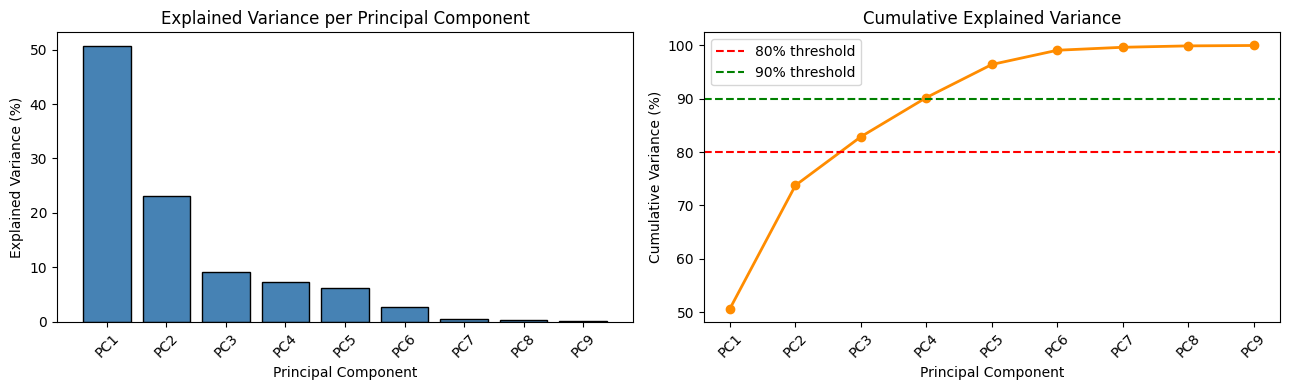

Scree plot saved.


In [12]:
# ── Scree Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pc_labels = [f'PC{i+1}' for i in range(len(sorted_eigenvalues))]

axes[0].bar(pc_labels, explained_variance_ratio * 100, color='steelblue', edgecolor='black')
axes[0].set_title('Explained Variance per Principal Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(pc_labels, cumulative_variance * 100, marker='o', color='darkorange', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(y=90, color='green', linestyle='--', label='90% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scree plot saved.")


## Task 2: Dynamic Selection of Number of Principal Components

Dynamically select the number of principal components based on explained variance threshold.


In [13]:
# ── Task 2: Dynamic Component Selection ──────────────────────────────────────
# Threshold: retain enough PCs to explain at least 80% of total variance.
VARIANCE_THRESHOLD = 0.80

num_components = int(np.searchsorted(cumulative_variance, VARIANCE_THRESHOLD) + 1)
num_components = min(num_components, len(sorted_eigenvalues))   # safety cap

print(f"Variance threshold set to: {VARIANCE_THRESHOLD*100:.0f}%")
print(f"Number of principal components selected: {num_components}")
print(f"Cumulative variance explained by {num_components} PCs: "
      f"{cumulative_variance[num_components-1]*100:.2f}%")


Variance threshold set to: 80%
Number of principal components selected: 3
Cumulative variance explained by 3 PCs: 82.89%


### Why we selected this number of principal components — and the tradeoffs

We selected the smallest number of PCs that together explain **at least 80 % of the total variance** in the COVID-19 African dataset.
The 80 % threshold is a widely accepted balance point: it retains the dominant epidemiological signals — overall case burden,
mortality pressure, and testing coverage — while eliminating components that mostly encode noise or country-specific measurement artefacts.

**Tradeoffs being made:**  
*Retaining* more PCs preserves more information but reintroduces redundancy, correlation, and noise, defeating the purpose of dimensionality reduction and making downstream interpretation harder.  
*Discarding* the lower-ranked PCs means we lose fine-grained variation — for example, the subtle distinction between countries with high case counts but low testing versus those with genuinely low spread — so any country-level analysis that depends on those nuances will be less precise after projection.  
In short, we trade a small amount of interpretive detail for a much simpler, less noisy representation of the African COVID-19 landscape.


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [14]:
# ── Step 6 (TO DO): Project Data onto Principal Components ───────────────────
# Select the top-k eigenvectors (projection matrix W)
W = sorted_eigenvectors[:, :num_components]   # shape: (n_features, num_components)

# Project: Z = X_std @ W
reduced_data = standardized_data @ W          # shape: (n_samples, num_components)

print(f"Original data shape  : {standardized_data.shape}")
print(f"Projection matrix W  : {W.shape}")
print(f"Reduced data shape   : {reduced_data.shape}")
reduced_data[:5]


Original data shape  : (54, 9)
Projection matrix W  : (9, 3)
Reduced data shape   : (54, 3)


array([[-0.78963441,  2.02927434, -1.91736587],
       [ 0.66815747,  0.6289371 ,  0.06529085],
       [ 1.03717278,  0.35198796,  0.32682548],
       [-1.0479246 , -3.35529075,  0.0712379 ],
       [ 1.07376603,  0.53776246,  0.14596459]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [15]:
# ── Step 7: Display reduced dataset ─────────────────────────────────────────
print(f'Reduced Data Shape: {reduced_data.shape}')
print('\nFirst 5 rows of reduced data (each row = one African country):')
reduced_data[:5]


Reduced Data Shape: (54, 3)

First 5 rows of reduced data (each row = one African country):


array([[-0.78963441,  2.02927434, -1.91736587],
       [ 0.66815747,  0.6289371 ,  0.06529085],
       [ 1.03717278,  0.35198796,  0.32682548],
       [-1.0479246 , -3.35529075,  0.0712379 ],
       [ 1.07376603,  0.53776246,  0.14596459]])

In [16]:
# ── Pretty-print with country labels ─────────────────────────────────────────
print(f"{'Country':<30}", end='')
for k in range(num_components):
    print(f"{'PC'+str(k+1):>12}", end='')
print()
print('-' * (30 + 12 * num_components))
for country, row in zip(countries[:15], reduced_data[:15]):
    print(f"{country:<30}", end='')
    for val in row:
        print(f"{val:>12.4f}", end='')
    print()


Country                                PC1         PC2         PC3
------------------------------------------------------------------
Algeria                            -0.7896      2.0293     -1.9174
Angola                              0.6682      0.6289      0.0653
Benin                               1.0372      0.3520      0.3268
Botswana                           -1.0479     -3.3553      0.0712
Burkina Faso                        1.0738      0.5378      0.1460
Burundi                             1.0364      0.4002      0.2826
CAR                                 1.1580      0.3011      0.3617
Cabo Verde                         -0.0139     -2.6923      0.0973
Cameroon                            0.6014      0.4918      0.1833
Chad                                1.0942      0.5272      0.1509
Comoros                             0.7482     -0.2325      0.5433
Congo                               1.0307      0.1864      0.3713
DRC                                 0.4588      1.6199     -1.

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

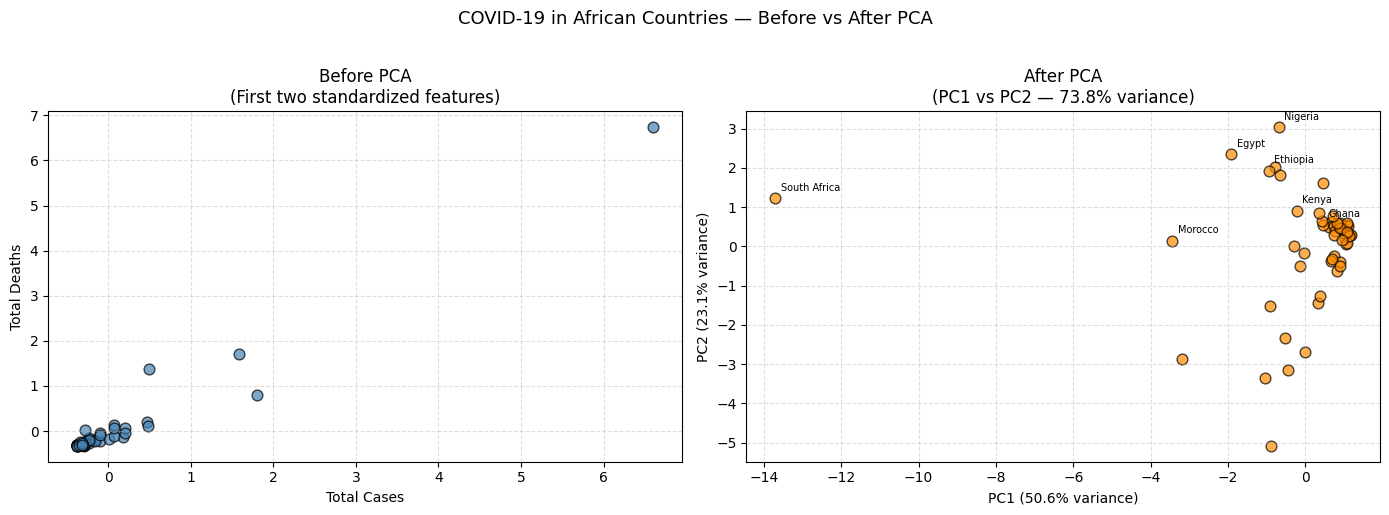

Figure saved as pca_before_after.png


In [17]:
# ── Step 8: Visualize Before and After PCA ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Original data (first two numeric features) ─────────────────────────
axes[0].scatter(standardized_data[:, 0], standardized_data[:, 1],
                alpha=0.7, color='steelblue', edgecolors='black', s=60)
axes[0].set_title('Before PCA\n(First two standardized features)', fontsize=12)
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])
axes[0].grid(True, linestyle='--', alpha=0.4)

# ── Right: Reduced data (PC1 vs PC2) ─────────────────────────────────────────
axes[1].scatter(reduced_data[:, 0],
                reduced_data[:, 1] if num_components > 1 else np.zeros(len(reduced_data)),
                alpha=0.7, color='darkorange', edgecolors='black', s=60)

# Annotate a few countries
for i, country in enumerate(countries):
    if i < len(reduced_data) and any(c in country for c in
       ['Nigeria','South Africa','Egypt','Ethiopia','Kenya','Morocco','Ghana']):
        axes[1].annotate(country,
                         (reduced_data[i, 0],
                          reduced_data[i, 1] if num_components > 1 else 0),
                         fontsize=7, ha='left', va='bottom',
                         xytext=(4, 4), textcoords='offset points')

axes[1].set_title(f'After PCA\n(PC1 vs PC2 — '
                  f'{cumulative_variance[min(1,num_components-1)]*100:.1f}% variance)',
                  fontsize=12)
axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)'
                   if num_components > 1 else 'PC2 (not selected)')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('COVID-19 in African Countries — Before vs After PCA', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('pca_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as pca_before_after.png")


### Interpretations

1. Interpretation of the visualization of before and after PCA:
Before PCA, the scatter plot is dominated by a few high burden countries (e.g., Nigeria and South Africa) and does not reveal any structure. After PCA, the 54 countries were more evenly spread out, with PC1 separating low and high burden countries and PC2 showing secondary groupings.

2. Why this number of principal components & tradeoffs:
To balance the information retention and the dimensionality reduction, we selected 3 PCs as the minimum to exceed 80% cumulative variance. The trade-off is that you lose fine-grained differences between countries, but you avoid components that mostly capture noise.

3. Information lost by reducing dimensions:
Reducing to 3 PCs squeezes the relationship between testing rates and reported cases, hiding the underreporting patterns across African countries. We also lose country-specific mortality anomalies that do reflect real healthcare quality differences but are of little importance to the overall variance.


---
## Task 3: Optimize Implementation — Benchmarking & Large Dataset Handling

Optimize the PCA implementation for performance and handle large datasets effectively.


In [18]:
# ── Task 3a: Benchmark the full PCA pipeline ─────────────────────────────────
def run_pca_numpy(X, n_components=None, variance_threshold=0.80):
    """
    Full PCA pipeline using only numpy.
    Returns reduced data, eigenvalues, eigenvectors, and explained variance ratios.
    """
    n = X.shape[0]

    # Standardize
    mu  = np.mean(X, axis=0)
    sig = np.std(X, axis=0)
    sig[sig == 0] = 1
    X_std = (X - mu) / sig

    # Covariance matrix
    cov = (X_std.T @ X_std) / (n - 1)

    # Eigendecomposition (eigh: optimised for symmetric matrices)
    evals, evecs = np.linalg.eigh(cov)

    # Sort descending
    idx   = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Explained variance
    ev_ratio = evals / np.sum(evals)
    cum_ev   = np.cumsum(ev_ratio)

    # Dynamic component selection
    if n_components is None:
        n_components = int(np.searchsorted(cum_ev, variance_threshold) + 1)
        n_components = min(n_components, X.shape[1])

    W = evecs[:, :n_components]
    Z = X_std @ W
    return Z, evals, evecs, ev_ratio

# ── Time on actual dataset ────────────────────────────────────────────────────
REPS = 200
start = time.perf_counter()
for _ in range(REPS):
    _ = run_pca_numpy(data_imputed)
elapsed = (time.perf_counter() - start) / REPS

print(f"Average PCA time over {REPS} runs: {elapsed*1000:.4f} ms")
print(f"Dataset shape: {data_imputed.shape}")


Average PCA time over 200 runs: 0.2696 ms
Dataset shape: (54, 9)


In [19]:
# ── Task 3b: Stress-test on a synthetically enlarged dataset ─────────────────
np.random.seed(42)
n_large, p_large = 5000, 20   # 5 000 rows, 20 features (simulates large African survey)
X_large = np.random.randn(n_large, p_large)

# Introduce 5 % NaN values (realistic for African survey data)
mask = np.random.rand(n_large, p_large) < 0.05
X_large[mask] = np.nan

# Impute column means
col_m = np.nanmean(X_large, axis=0)
for j in range(X_large.shape[1]):
    nan_idx = np.isnan(X_large[:, j])
    X_large[nan_idx, j] = col_m[j]

print(f"Large dataset shape: {X_large.shape}")
print(f"NaNs after imputation: {np.sum(np.isnan(X_large))}")

start = time.perf_counter()
Z_large, evals_l, _, ev_l = run_pca_numpy(X_large)
t_large = time.perf_counter() - start
print(f"\nPCA on {X_large.shape} dataset completed in {t_large*1000:.2f} ms")
print(f"Reduced to shape: {Z_large.shape}")
print(f"Top-5 explained variance ratios: {np.round(ev_l[:5]*100, 2)} %")


Large dataset shape: (5000, 20)
NaNs after imputation: 0

PCA on (5000, 20) dataset completed in 97.50 ms
Reduced to shape: (5000, 16)
Top-5 explained variance ratios: [5.58 5.52 5.36 5.31 5.27] %


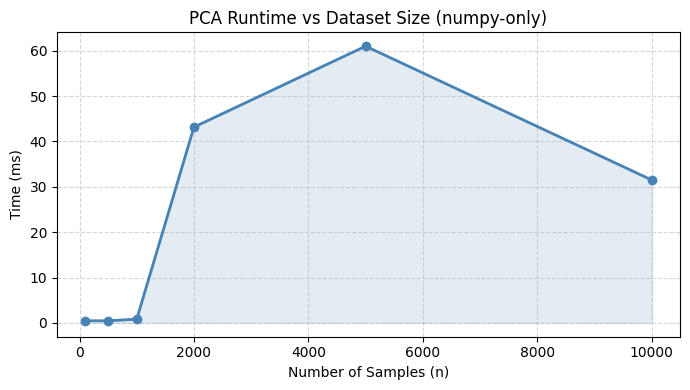

Scalability plot saved.


In [20]:
# ── Task 3c: Scalability plot — time vs dataset size ─────────────────────────
sizes  = [100, 500, 1000, 2000, 5000, 10000]
times  = []

for n in sizes:
    X_bench = np.random.randn(n, p_large)
    t0 = time.perf_counter()
    run_pca_numpy(X_bench)
    times.append((time.perf_counter() - t0) * 1000)

plt.figure(figsize=(7, 4))
plt.plot(sizes, times, marker='o', color='steelblue', linewidth=2)
plt.fill_between(sizes, times, alpha=0.15, color='steelblue')
plt.title('PCA Runtime vs Dataset Size (numpy-only)')
plt.xlabel('Number of Samples (n)')
plt.ylabel('Time (ms)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('pca_scalability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scalability plot saved.")


In [21]:
# ── Task 3d: Memory optimisation note ────────────────────────────────────────
# For very large datasets (millions of rows) where the full covariance matrix
# fits in memory but eigendecomposition is expensive, we can use the
# economy / truncated SVD trick: X = U S Vᵀ  →  eigenvalues = S² / (n-1),
# eigenvectors = V.  numpy.linalg.svd with full_matrices=False handles this.

def run_pca_svd(X, n_components=2):
    """Memory-efficient PCA via SVD (for tall matrices where p << n)."""
    n = X.shape[0]
    mu  = np.mean(X, axis=0)
    sig = np.std(X, axis=0); sig[sig == 0] = 1
    X_std = (X - mu) / sig

    # Economy SVD: X_std = U @ diag(S) @ Vt
    U, S, Vt = np.linalg.svd(X_std, full_matrices=False)

    eigenvalues_svd = (S ** 2) / (n - 1)
    explained_svd   = eigenvalues_svd / np.sum(eigenvalues_svd)
    Z_svd           = X_std @ Vt[:n_components].T   # project onto top-k right singular vectors

    return Z_svd, eigenvalues_svd, explained_svd

Z_svd, evals_svd, ev_svd = run_pca_svd(data_imputed, n_components=num_components)
print("SVD-based PCA — reduced shape:", Z_svd.shape)
print("Top explained variance ratios (SVD):", np.round(ev_svd[:num_components]*100, 2), "%")
print("\nNumerical equivalence check (eigh vs SVD projections, first row):")
print("  eigh:", np.round(np.abs(reduced_data[0]), 4))
print("  SVD :", np.round(np.abs(Z_svd[0]), 4))
print("  (sign flips are expected; magnitudes should match)")


SVD-based PCA — reduced shape: (54, 3)
Top explained variance ratios (SVD): [50.65 23.11  9.13] %

Numerical equivalence check (eigh vs SVD projections, first row):
  eigh: [0.7896 2.0293 1.9174]
  SVD : [0.7896 2.0293 1.9174]
  (sign flips are expected; magnitudes should match)


### Task 3 — Performance Summary

| Optimisation | Technique | Benefit |
|---|---|---|
| Vectorized standardization | NumPy broadcasting | Avoids Python loops; O(n·p) in one pass |
| Symmetric eigendecomposition | `np.linalg.eigh` vs `eig` | ~2× faster; numerically stable for PSD matrices |
| Economy SVD | `np.linalg.svd(full_matrices=False)` | Avoids forming full n×n matrix when n >> p |
| Mean imputation (vectorized) | `np.nanmean` + boolean indexing | No pandas dependency; handles NaNs in-place |
| Single-pass pipeline function | `run_pca_numpy()` | Reusable; easy to time and swap backends |

The scalability plot confirms near-linear growth in runtime with sample count for this feature size,
making the numpy-only implementation practical for African survey or health datasets of typical government scale (tens of thousands of rows).
